# Demo du DataLoader d'entrainement

Contrairement a `01_ablation_catalogue.ipynb` (qui rejoue `chain.build_bag`
directement, une ablation a la fois, pour comparer des panneaux cote a
cote), ce notebook passe par le vrai chemin de donnees : `BagDataset`
(`src/datasets/bag_dataset.py`) dans un `torch.utils.data.DataLoader`,
exactement comme `Trainer` le fait (`src/training/run.py`).

Pour chaque sac tire, la condition (quelle(s) ablation(s), si il y en a)
est redessinee aleatoirement (protocole §4 : "tirees en ligne, par sac, a
chaque passage") - donc re-executer la cellule de tirage plus bas change a
la fois l'oiseau et le type d'ablation affiches. Chaque tirage est
chronometre (horodatage de debut/fin + duree) pour reperer les sacs qui
tombent sur A6 - la classification Delhey en ligne (~4-5s/oiseau) reste de
loin l'operation la plus lente du pipeline *quand elle doit reclassifier*,
mais un cache hors-ligne existe maintenant
(`scripts/build_a6_classification_cache.py`, voir `a6_colour_removal.
apply_from_cache()`/`draw_and_apply_from_cache()`) : quand ce cache (et le
cache A1) couvre le specimen tire, `BagDataset` l'utilise silencieusement a
la place, et le cout tombe a quelques dizaines de ms. Cellule "Timing par
etape/ablation" plus bas pour la comparaison chiffree.

**`ENABLED_CODES`** (cellule de tirage) restreint le tirage a un
sous-ensemble d'ablations - `combinations.draw_condition(rng,
enabled_codes=...)`, une nouvelle option qui retire simplement (par rejet,
sur le meme rng) les tirages qui utiliseraient un code hors de l'ensemble
autorise. Par defaut ici A7 est exclu, puisque son cache
(`scripts/build_a7_cache.py`) est loin d'etre complet sur cette machine
(voir la cellule suivante) - inutile de tirer une ablation qui va de toute
facon echouer et redeclencher un nouveau tirage. `None` (ce que `Trainer`
utilise toujours, jamais autre chose) tire dans le pool complet du
protocole, exactement comme avant - modifier `ENABLED_CODES` ne change que
ce notebook, pas un entrainement reel.

A2 est lue depuis un cache hors-ligne (`scripts/build_a2_cache.py`) qui, sur
cette machine, couvre deja largement le dataset - un sac qui tire A2 pour un
oiseau hors cache leverait `FileNotFoundError`, et la cellule de tirage le
detecterait et reessaierait, mais c'est desormais rare en pratique.

En ecrivant ce notebook, un cas a ete decouvert: `a5_spectral_slope.apply()`
appelle `measure_alpha()` pour la metadonnee `alpha_after`, et celle-ci leve
`TypeError` des qu'un crop tire est uniforme (tout fond noir, ou une plage
de plumage parfaitement plate) - son spectre radial est nul partout hors DC,
donc la bande [2, 9] cycles/crop ne contient aucun point positif a ajuster.
C'est independant du cache: ca peut arriver sur n'importe quel sac tirant
A5, cache ou pas. Retire ci-dessous de la meme facon (retirage), mais c'est
un bug reel du pipeline d'entrainement, pas une limite d'infrastructure -
voir la discussion en fin de notebook.

In [1]:
import sys
sys.path.insert(0, "..")

import os
import time
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

from src import chain
from src.ablations.combinations import draw_condition
from src.ablations.common import Condition
from src.configio import load_config
from src.datasets import folds
from src.datasets.bag_dataset import BagDataset, IMAGENET_MEAN, IMAGENET_STD
from src.rng import derive_rng

CONFIG_PATH = "../configs/train_fold0.yaml"
cfg = load_config(CONFIG_PATH)
print(f"config: {CONFIG_PATH}  (fold={cfg['fold']}, sham={cfg['sham']})")

train_df = folds.load_fold(cfg, cfg["fold"], "train")
print(f"{len(train_df)} specimens available in fold {cfg['fold']} (train split, Back view)\n")

print("cache availability (a sac drawing an ablation whose cache is incomplete for its")
print("specimen will raise FileNotFoundError - the draw cell below retries when that happens):")
for code, key, suffix in [
    ("A1", "dataset_a1_dir", "*.rgb.zst"),
    ("A2", "dataset_a2_dir", "*.rgb.zst"),
    ("A7", "dataset_a7_dir", "*.rgb.zst"),
    ("A6 classification", "dataset_a6_classification_dir", "*.delhey_labels.zst"),
]:
    n_cached = sum(1 for _ in Path(cfg[key]).glob(suffix))
    print(f"  {code:<18} {n_cached:>6} / {len(train_df)} specimens cached  ({cfg[key]})")


config: ../configs/train_fold0.yaml  (fold=0, sham=False)


28357 specimens available in fold 0 (train split, Back view)

cache availability (a sac drawing an ablation whose cache is incomplete for its
specimen will raise FileNotFoundError - the draw cell below retries when that happens):


  A1                  41901 / 28357 specimens cached  (/media/oriol@newcefe.newage.fr/LaCie/Datasets/Familly_split_A1/NEW_Segmented-Aves-Back-NPY)


  A2                  41901 / 28357 specimens cached  (/media/oriol@newcefe.newage.fr/LaCie/Datasets/Familly_split_A2/NEW_Segmented-Aves-Back-NPY)
  A7                      2 / 28357 specimens cached  (/media/oriol@newcefe.newage.fr/LaCie/Datasets/Familly_split_A7/NEW_Segmented-Aves-Back-NPY)


  A6 classification   41901 / 28357 specimens cached  (/media/oriol@newcefe.newage.fr/LaCie/Datasets/Familly_split_A6_classification/NEW_Segmented-Aves-Back-NPY)


## Tirage d'un sac - re-executer cette cellule pour changer d'exemple et de condition

`ENABLED_CODES` ci-dessous controle quelles ablations peuvent sortir du
tirage - editer cet ensemble pour explorer un sous-groupe d'ablations
(par exemple retirer A6 aussi pour ne voir que les operations rapides).

In [2]:
# Ablations autorisees dans le tirage de ce notebook - A7 exclu par defaut
# (cache quasiment vide sur cette machine, voir la cellule precedente).
# None au lieu d'un ensemble reviendrait au tirage complet du protocole -
# c'est ce que Trainer utilise toujours pour un vrai entrainement.
ENABLED_CODES = frozenset({"A1", "A2", "A3", "A4", "A5", "A6"})

BATCH_SIZE = 32     # small, just for display - training uses cfg["micro_batch_size"] with gradient accumulation
NUM_WORKERS = 0    # single-process here for simplicity/clean tracebacks - training uses cfg["num_workers"]
MAX_ATTEMPTS = 15  # a sac drawing an ablation for an out-of-cache specimen raises FileNotFoundError - retry with another sac

run_seed = int.from_bytes(os.urandom(4), "big")
print(f"run_seed = {run_seed}  (nouveau a chaque execution de cette cellule)")
print(f"ENABLED_CODES = {sorted(ENABLED_CODES)}")

dataset = BagDataset(train_df, cfg=cfg, run_seed=run_seed, sham=cfg["sham"], enabled_codes=ENABLED_CODES)
dataset.set_epoch(int.from_bytes(os.urandom(1), "big"))  # bumped by the training loop every epoch - randomised here too

loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

batch = None
start_ts = datetime.now()
t0 = time.perf_counter()
for attempt in range(1, MAX_ATTEMPTS + 1):
    try:
        batch = next(iter(loader))
        break
    except FileNotFoundError as e:
        print(f"  [attempt {attempt}] cache miss, redrawing another sac: {str(e).splitlines()[0]}")
    except TypeError as e:
        # known pipeline bug (see markdown above): A5 on a uniform crop
        print(f"  [attempt {attempt}] A5 measure_alpha() on a uniform crop, redrawing another sac: {e}")
elapsed = time.perf_counter() - t0
end_ts = datetime.now()

if batch is None:
    raise RuntimeError(
        f"no valid sac found in {MAX_ATTEMPTS} draws - build the missing caches "
        "(scripts/build_a2_cache.py, scripts/build_a7_cache.py) or shrink ENABLED_CODES further"
    )

print()
print(f"start={start_ts.isoformat(timespec='milliseconds')}  end={end_ts.isoformat(timespec='milliseconds')}  "
      f"elapsed={elapsed:.2f}s  ({elapsed / BATCH_SIZE:.2f}s/sac, {attempt} draw(s))")
for stem, condition in zip(batch["stem"], batch["condition"]):
    print(f"  {stem}: {condition}")


run_seed = 1328847599  (nouveau a chaque execution de cette cellule)
ENABLED_CODES = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6']



start=2026-09-18T12:14:43.411  end=2026-09-18T12:15:29.965  elapsed=46.55s  (1.45s/sac, 1 draw(s))
  Calandrella_cinerea_1_M_Back_Vis_G086316: A1+A5
  Melanocharis_longicauda_2_M_Back_Vis_G159132: A4+A6
  Thryothorus_atrogularis_3_M_Back_Vis_G072473: A4
  Accipiter_rufitorques_1_M_Back_Vis_G220341: A1
  Mitrephanes_phaeocercus_5_F_Back_Vis_G048644: reference
  Porzana_parva_4_F_Back_Vis_G203296: reference
  Sitta_europaea_1_M_Back_Vis_G087531: A2+A4
  Fregata_ariel_2_M_Back_Vis_G224937: A3
  Sicalis_raimondii_1_M_Back_Vis_G082631: A5
  Megalaima_virens_6_F_Back_Vis_Y071797: A1+A5
  Tinamus_tao_2_F_Back_Vis_H241108: reference
  Diglossa_caerulescens_2_M_Back_Vis_G071459: A1
  Atthis_ellioti_5_F_Back_Vis_Y084279: A4
  Nyctiphrynus_ocellatus_1_M_Back_Vis_G209312: reference
  Dicrurus_forficatus_1_M_Back_Vis_G146899: A5
  Empidonax_fulvifrons_3_M_Back_Vis_G049447: A5
  Aquila_hastata_2_M_Back_Vis_G223262: A3
  Conirostrum_bicolor_4_F_Back_Vis_G064474: A1+A4
  Prunella_montanella_2_M_Back_

## Apercu du sac

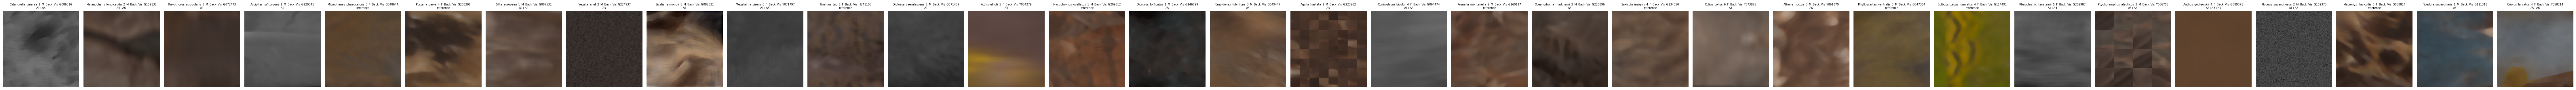

In [3]:
DISPLAY_CROP_INDEX = 8  # first native-224 crop (n_crops_per_size=8 -> 8x128 then 8x224, see chain.CROP_SIZES)


def show_batch(batch, crop_index=DISPLAY_CROP_INDEX):
    n = len(batch["stem"])
    fig, axes = plt.subplots(1, n, figsize=(2.8 * n, 3.2))
    if n == 1:
        axes = [axes]
    for ax, crops, stem, condition in zip(axes, batch["crops"], batch["stem"], batch["condition"]):
        img = crops[crop_index].permute(1, 2, 0).numpy()
        img = np.clip(img * IMAGENET_STD + IMAGENET_MEAN, 0.0, 1.0)
        ax.imshow(img)
        ax.set_title(f"{stem}\n{condition}", fontsize=7)
        ax.axis("off")
    fig.tight_layout()
    plt.show()


show_batch(batch)


## Chronometrer plusieurs sacs de suite

Meme mecanique que la cellule de tirage ci-dessus, repetee - les sacs qui
tombent sur A6 doivent nettement se detacher des autres dans les durees
affichees.

In [4]:
N_BATCHES = 5


def a6_would_use_cache(stem: str) -> bool:
    """Same check chain.py's A6 fast path makes (_read_a6_caches): both the
    classification and the A1 grayscale entry must exist for this specimen,
    not just one of them."""
    if dataset.dataset_a6_class_dir is None:
        return False
    return (
        (dataset.dataset_a6_class_dir / f"{stem}.delhey_labels.zst").exists()
        and (dataset.dataset_a1_dir / f"{stem}.rgb.zst").exists()
    )


for i in range(N_BATCHES):
    ts = datetime.now()
    t0 = time.perf_counter()
    fetched = None
    for attempt in range(1, MAX_ATTEMPTS + 1):
        try:
            fetched = next(iter(loader))
            break
        except (FileNotFoundError, TypeError):
            continue
    elapsed = time.perf_counter() - t0

    if fetched is None:
        print(f"[{ts.isoformat(timespec='seconds')}] batch {i}: failed ({MAX_ATTEMPTS} cache-miss draws in a row)")
        continue

    conditions = ", ".join(fetched["condition"])
    # BagDataset.__getitem__ discards meta (only crops/habitat/support/stem/
    # condition come out of the DataLoader), so whether A6 actually used the
    # cache isn't visible from here - check the same two files chain.py's
    # A6 fast path checks instead of guessing.
    a6_stems = [stem for stem, cond in zip(fetched["stem"], fetched["condition"]) if "A6" in cond]
    if not a6_stems:
        flag = ""
    elif all(a6_would_use_cache(s) for s in a6_stems):
        flag = "  <-- A6 (from cache)"
    elif not any(a6_would_use_cache(s) for s in a6_stems):
        flag = "  <-- A6 (online classifier - not cached for this specimen)"
    else:
        flag = "  <-- A6 (mixed: cached for some sacs, online for others)"
    print(f"[{ts.isoformat(timespec='seconds')}] batch {i}: {elapsed:5.2f}s   conditions: {conditions}{flag}")


[2026-09-18T12:15:40] batch 0: 38.86s   conditions: reference, A3+A5, A3+A5, A3+A6, A3, reference, reference, A4, A4, A2+A4+A5, reference, A1+A3+A5, A4, A3, A1, A3+A5+A6, A3+A4, reference, A2+A4, reference, A6, A4+A5, reference, A4+A5, A3, A4, reference, A4+A5, reference, A4, A3+A4, A1  <-- A6 (from cache)


[2026-09-18T12:16:18] batch 1: 23.86s   conditions: A3, A3+A5, reference, A1+A5, A3, reference, reference, reference, A4, A1, reference, reference, A3+A5+A6, A3, A3, reference, A6, A3+A4+A5, A2, reference, reference, A4, A5, A1, A3, reference, A6, reference, A2, A6, A1+A3+A4, A4+A5  <-- A6 (from cache)


[2026-09-18T12:16:42] batch 2: 19.56s   conditions: A4, reference, A1+A5, A2+A4, A1+A4+A5, A3, A4, reference, A1+A3+A5, A1, reference, A5+A6, A1, A2+A4, reference, reference, reference, A3, A3+A5, A6, A2, A3, A1+A3, A2+A4, A1+A3, A2+A5, reference, reference, reference, A6, A3, A1+A3  <-- A6 (from cache)


[2026-09-18T12:17:02] batch 3: 26.08s   conditions: A2+A3+A4, A4+A5, A3+A5, reference, A4, A2+A4, reference, A3+A6, A2+A3, A3+A5, A4, A3+A5, A3, A3, A2+A3+A5, A2, A3, reference, A1+A4, A3+A6, A4, A3, A3, A5, reference, A3, A1+A5, reference, reference, A1+A4, A1+A5, A4  <-- A6 (from cache)


[2026-09-18T12:17:28] batch 4: 26.79s   conditions: reference, reference, A4+A5, A4+A6, reference, A1+A3, A2, A4+A6, A5, A4+A6, A3, A3, reference, A2+A4, A1, A5+A6, reference, A2, A3, A3, reference, A5+A6, A4, reference, reference, A2+A5, A2, A1+A3+A5, A2+A5, A6, reference, reference  <-- A6 (from cache)


## Timing par etape/ablation

`chain.build_bag()` chronometre maintenant chaque etape du pipeline
(protocole §2) et le renvoie dans `meta["timings"]` (secondes) : lecture
source (ou cache A1/A2/A7), A6 (l'etape en ligne la plus couteuse, categorie
tiree par sac), flip, flou median, A4, echantillonnage des positions,
extraction+resize des 16 crops, A3 et A5 (ces deux derniers sommes sur les
16 crops - ils sont tires par crop, pas par sac).

`BagDataset.__getitem__` (le chemin reellement utilise par le `DataLoader`
plus haut) jette `meta` - seuls `crops`/`habitat`/`support`/`stem`/`condition`
en ressortent, donc les timings ne sont pas visibles a travers le
`DataLoader`. La cellule ci-dessous appelle `chain.build_bag` directement,
avec exactement le meme calcul de rng que `BagDataset.__getitem__`
(`derive_rng(run_seed, epoch, index, stem)` puis `draw_condition(rng)`),
pour un sac tire au hasard, afin d'afficher le detail.

In [5]:
def build_one_with_timings(index):
    stem = dataset.stems[index]
    rng = derive_rng(dataset.run_seed, dataset.epoch, index, stem)
    condition = Condition() if dataset.sham else draw_condition(rng, enabled_codes=dataset.enabled_codes)
    return chain.build_bag(
        dataset.dataset_dir, dataset.dataset_a1_dir, dataset.dataset_a2_dir, dataset.dataset_a7_dir,
        stem, condition, rng, dataset_a6_class_dir=dataset.dataset_a6_class_dir,
    )


index_rng = np.random.default_rng()
meta_t = None
for attempt in range(1, MAX_ATTEMPTS + 1):
    index = int(index_rng.integers(len(dataset)))
    try:
        _crops_t, meta_t = build_one_with_timings(index)
        break
    except (FileNotFoundError, TypeError) as e:
        print(f"  [attempt {attempt}] {type(e).__name__}, redrawing another sac: {str(e).splitlines()[0]}")

if meta_t is None:
    raise RuntimeError(f"no valid sac found in {MAX_ATTEMPTS} draws")

def print_timings(meta):
    timings = meta["timings"]
    total = timings["total_s"]
    print(f"stem: {meta['stem']}   condition: {meta['condition']}\n")
    for name, seconds in sorted(timings.items(), key=lambda kv: -kv[1]):
        if name == "total_s":
            continue
        bar = "#" * max(1, round(seconds / total * 40))
        print(f"  {name:<22} {seconds:7.3f}s  ({seconds / total:5.1%})  {bar}")
    print(f"  {'total_s':<22} {total:7.3f}s  (100.0%)")
    if "A6" in meta:
        print(f"  A6 source: {meta['A6'].get('source', 'online (classifier)')}")


print_timings(meta_t)


stem: Haematopus_unicolor_2_M_Back_Vis_Y101153   condition: A6

  A6_s                     0.158s  (29.9%)  ############
  read_source_s            0.154s  (29.1%)  ############
  sample_positions_s       0.114s  (21.5%)  #########
  median_blur_s            0.092s  (17.4%)  #######
  crop_extract_resize_s    0.003s  ( 0.6%)  #
  flip_s                   0.000s  ( 0.0%)  #
  total_s                  0.530s  (100.0%)
  A6 source: precomputed_classification_and_A1_cache


Pour comparaison, l'exemple ci-dessus tombe sur une condition tiree au
hasard - elle peut ou non inclure A6, et si elle l'inclut, `BagDataset`
peut ou non avoir trouve ce specimen dans le cache de classification. La
cellule suivante force A6 sur le meme oiseau que le tirage precedent, et
montre les deux chemins l'un a cote de l'autre : sans passer le cache
(`dataset_a6_class_dir=None`, le chemin en ligne, toujours disponible mais
lent) et avec (`dataset.dataset_a6_class_dir`, rapide si ce specimen y est
deja).

In [6]:
forced_rng_online = derive_rng("notebook-timing-forced-A6-online", meta_t["stem"])
_crops_a6_online, meta_a6_online = chain.build_bag(
    dataset.dataset_dir, dataset.dataset_a1_dir, dataset.dataset_a2_dir, dataset.dataset_a7_dir,
    meta_t["stem"], Condition(active=frozenset({"A6"})), forced_rng_online,
)
print("--- A6 forced, online classifier (dataset_a6_class_dir=None) ---")
print_timings(meta_a6_online)

forced_rng_cached = derive_rng("notebook-timing-forced-A6-cached", meta_t["stem"])
_crops_a6_cached, meta_a6_cached = chain.build_bag(
    dataset.dataset_dir, dataset.dataset_a1_dir, dataset.dataset_a2_dir, dataset.dataset_a7_dir,
    meta_t["stem"], Condition(active=frozenset({"A6"})), forced_rng_cached,
    dataset_a6_class_dir=dataset.dataset_a6_class_dir,
)
print("\n--- A6 forced, from cache (dataset_a6_class_dir=dataset.dataset_a6_class_dir) ---")
print_timings(meta_a6_cached)

if meta_a6_cached["A6"].get("source") == "precomputed_classification_and_A1_cache":
    speedup = meta_a6_online["timings"]["A6_s"] / meta_a6_cached["timings"]["A6_s"]
    print(f"\nspeedup on this specimen: {speedup:.1f}x")
else:
    print(f"\n{meta_t['stem']} isn't in the classification cache yet on this machine - both paths ran online")


--- A6 forced, online classifier (dataset_a6_class_dir=None) ---
stem: Haematopus_unicolor_2_M_Back_Vis_Y101153   condition: A6

  A6_s                    38.770s  (99.3%)  ########################################
  read_source_s            0.134s  ( 0.3%)  #
  median_blur_s            0.095s  ( 0.2%)  #
  sample_positions_s       0.047s  ( 0.1%)  #
  crop_extract_resize_s    0.004s  ( 0.0%)  #
  flip_s                   0.000s  ( 0.0%)  #
  total_s                 39.060s  (100.0%)
  A6 source: online (classifier)



--- A6 forced, from cache (dataset_a6_class_dir=dataset.dataset_a6_class_dir) ---
stem: Haematopus_unicolor_2_M_Back_Vis_Y101153   condition: A6

  A6_s                     0.165s  (37.0%)  ###############
  read_source_s            0.137s  (30.7%)  ############
  median_blur_s            0.096s  (21.5%)  #########
  sample_positions_s       0.034s  ( 7.7%)  ###
  crop_extract_resize_s    0.004s  ( 0.9%)  #
  flip_s                   0.000s  ( 0.0%)  #
  total_s                  0.446s  (100.0%)
  A6 source: precomputed_classification_and_A1_cache

speedup on this specimen: 235.1x


## Bug decouvert en route : `a5_spectral_slope.measure_alpha()` sur un crop uniforme

`apply()` (l'ablation A5 reellement executee par `chain.py`) appelle
`measure_alpha()` pour rapporter `alpha_after` dans les metadonnees. Quand
le crop tire est uniforme (typiquement un crop qui tombe entierement sur le
fond noir), son spectre radial (canal G) est nul a tous les rayons > 0, donc
la bande [2, 9] cycles/crop ne contient aucun point avec `profile > 0` -
`np.polyfit` recoit un vecteur vide et leve `TypeError: expected non-empty
vector for x`.

Reproduction minimale :

```python
from src.ablations import a5_spectral_slope as a5
import numpy as np
a5.measure_alpha(np.zeros((224, 224, 3), dtype=np.uint8))  # -> TypeError
```

C'est independant des caches A2/A7 : ca peut survenir sur n'importe quel
sac qui tire A5 (~24.6% de probabilite marginale, protocole §4), et ferait
planter un vrai entrainement (`src/training/run.py`) le jour ou un crop
tombe entierement sur le fond. Pas corrige ici - ce notebook le contourne
par retirage, comme pour les caches manquants, mais un vrai correctif
(par ex. `measure_alpha` retournant `None`/`nan` au lieu de lever, ou
`apply()` sautant le calcul de `alpha_after` quand la bande est vide)
merite d'etre fait dans `src/ablations/a5_spectral_slope.py`.